In [2]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
import os
import pandas as pd
import matplotlib as mpl

In [25]:
os.chdir("/Users/gawasi001/Documents/Paper_msc/Data_uofm/SI_Figure6&7_Large_Transect/")

sal_vs = np.load("ANHA4-EJM010_salinity_LargeTransect_2007_2017.npz")
sal_vs = sal_vs['salinity']
sal_vs = np.nanmean(sal_vs, axis=0)

sal_vd = np.load("ANHA4-EJM012_salinity_LargeTransect_2007_2017.npz")
sal_vd = sal_vd['salinity']
sal_vd = np.nanmean(sal_vd, axis=0)

temp_vs = np.load("ANHA4-EJM010_temperature_LargeTransect_2007_2017.npz")
temp_vs = temp_vs['temperature']
temp_vs = np.nanmean(temp_vs, axis=0)

temp_vd = np.load("ANHA4-EJM012_temperature_LargeTransect_2007_2017.npz")
temp_vd = temp_vd['temperature']
temp_vd = np.nanmean(temp_vd, axis=0)

In [26]:
sal_dif_vdvs = sal_vd - sal_vs
temp_dif_vdvs = temp_vd - temp_vs

In [27]:
sal_dif_vdvs = np.where(mask == 0, np.nan, sal_dif_vdvs)
temp_dif_vdvs = np.where(mask == 0, np.nan, temp_dif_vdvs)

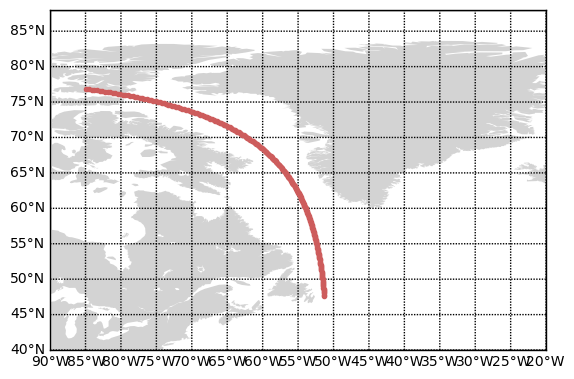

In [28]:
os.chdir('/Users/gawasi001/Documents/Paper_msc/Data_uofm/')

data_mask = xr.open_dataset('ANHA4_mask.nc')

mask = data_mask.variables['tmask']
mask = mask[0][0]

data_grid = xr.open_dataset('/Users/gawasi001/Documents/Paper_msc/Data_uofm/ANHA4-EJM010_y2017m12d31_gridT.nc')

lat = data_grid.variables['nav_lat_grid_T']
lon = data_grid.variables['nav_lon_grid_T']
lon = np.asarray(lon)
lat = np.asarray(lat)
depth = data_grid.variables['deptht']

depths = np.arange(0, 43)
lats = np.arange(300, 550)
lons = 190

s1 = lats # or slat_ds
s2 = lons # or slon_ds

sec = np.copy(mask)
sec[s1, s2] = 5
sec[np.where(sec != 5)] = np.nan

m = Basemap(projection='cyl', llcrnrlon=-90, llcrnrlat=40, urcrnrlon=-20, urcrnrlat=88, resolution = 'l')

m.drawmeridians(np.arange(0,360,5), labels=[0, 0, 0, 1])
m.drawparallels(np.arange(-90,90,5), labels=[1, 0, 0, 0])
m.drawmapboundary()
m.fillcontinents(color='lightgray')

lons = lon[s1,s2]
lats = lat[s1,s2]

x, y = m(lons,lats)

m.plot(x, y, marker=".",color='indianred')

plt.show()

In [29]:
sec_lat = lat[ s1, s2]
sec_lon = lon[ s1, s2]
sec_depth = depth[0: len(depth)-7]

tmask = data_mask.variables['tmask']
tmask = tmask[0, 0:len(sec_depth),s1, s2]

mask = np.zeros(np.shape(tmask))

for i in range(0, len(tmask)):
    for j in range(0, len(tmask[0])):
        if tmask[i][j] == np.float32(1):
            mask[i][j] = np.nan

In [30]:
xp, yp = np.meshgrid(sec_lon, sec_depth)

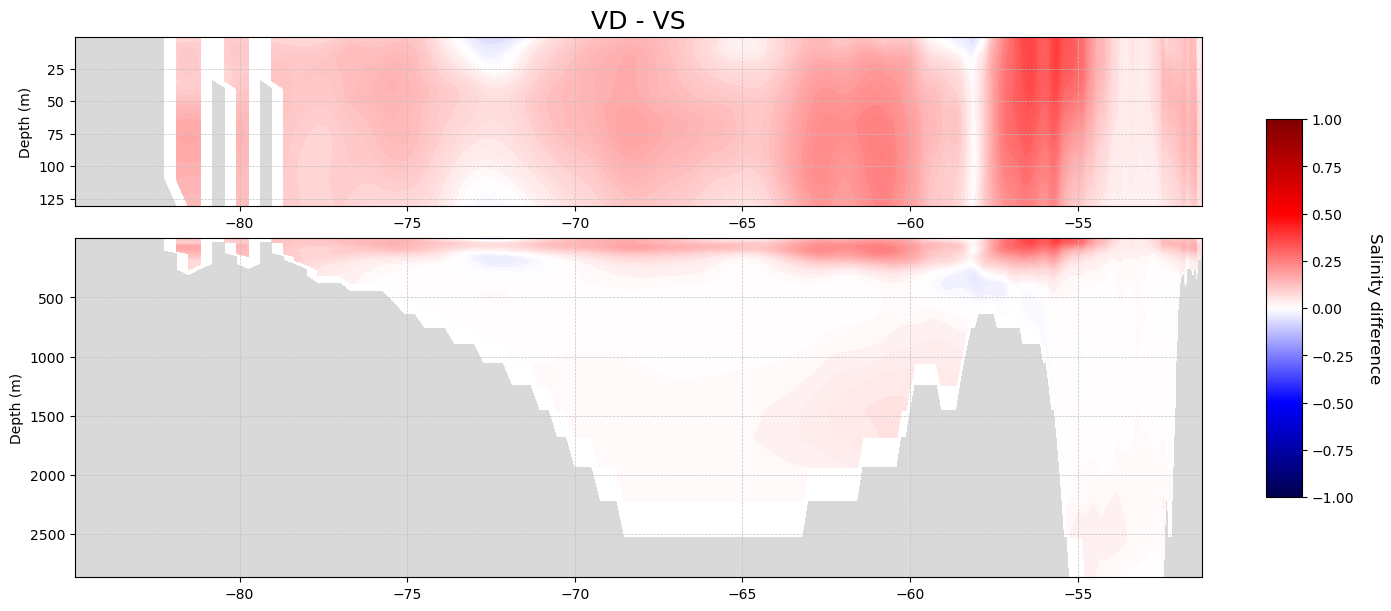

In [33]:
dpt = 24
vmin = -1
vmax =  1
levels = 50
cmap = 'seismic'

# Generate mesh grid
xp, yp = np.meshgrid(sec_lon, sec_depth)

# Create the figure with 2 rows (top: zoomed, bottom: full depth)
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(12, 6), constrained_layout=True, 
                       gridspec_kw={'height_ratios': [1, 2]})

# Top plot (0–250 m)
ax[0].contourf(xp[:dpt], yp[:dpt], sal_dif_vdvs[:dpt, :], levels=levels, vmin=vmin, vmax=vmax, cmap=cmap, zorder=1)
ax[0].contourf(xp[:dpt], yp[:dpt], mask[:dpt, :], cmap='Greys')
ax[0].set_ylim(max(sec_depth[:dpt]), min(sec_depth[:dpt]))
ax[0].grid(color='silver', linestyle='--', linewidth=0.5)
ax[0].set_title("VD - VS", fontsize=18)
ax[0].set_ylabel("Depth (m)")

# Bottom plot (full depth)
ax[1].contourf(xp, yp, sal_dif_vdvs, levels=levels, vmin=vmin, vmax=vmax, cmap=cmap, zorder=1)
ax[1].contourf(xp, yp, mask, cmap='Greys')
ax[1].set_ylim(max(sec_depth), min(sec_depth))
ax[1].grid(color='silver', linestyle='--', linewidth=0.5)
ax[1].set_ylabel("Depth (m)")

# Colorbar
cax = fig.add_axes([1.05, 0.18, 0.030, 0.63])
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
cb1 = mpl.colorbar.ColorbarBase(cax, cmap=cmap, norm=norm, orientation='vertical')
cb1.ax.set_ylabel('Salinity difference', rotation=270, labelpad=20, fontsize=12)
cb1.ax.ticklabel_format(style='sci', scilimits=(-1, 4), axis='both')

figure_title = 'Difference_LargeTransect_Salinity'
os.chdir("/Users/gawasi001/Documents/Paper_msc/Data_uofm/SI_Figure6&7_Large_Transect/")
plt.savefig(figure_title + '.png', dpi=300, bbox_inches='tight')
plt.show()

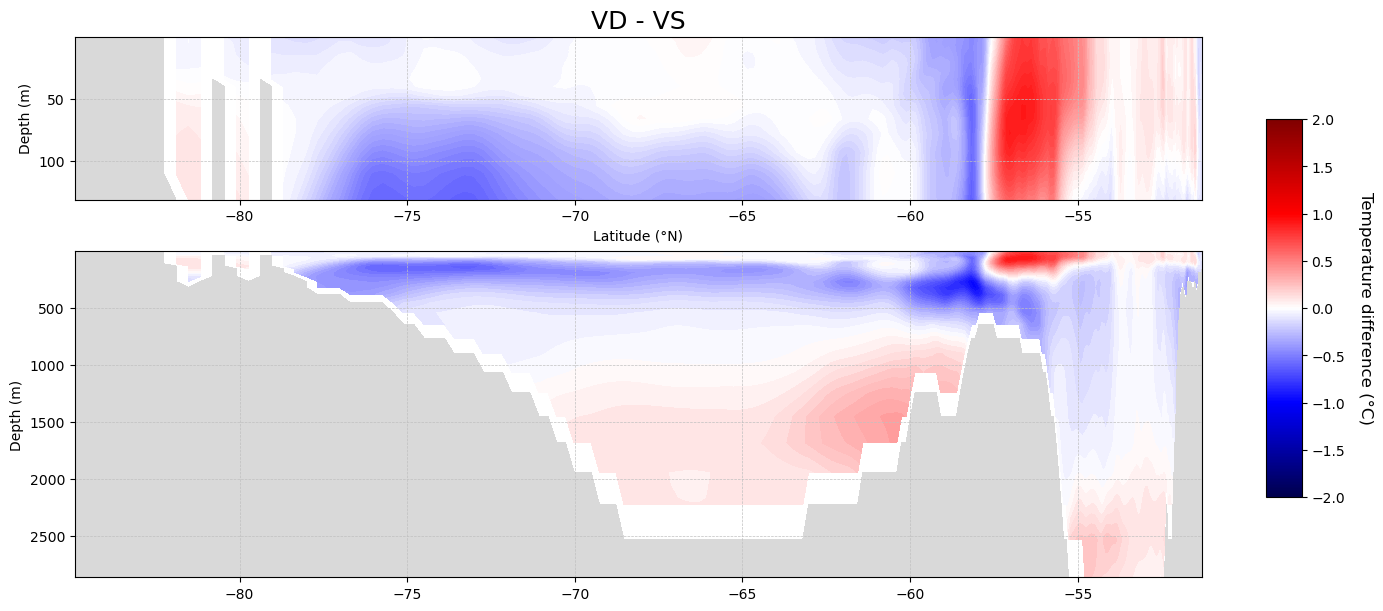

In [34]:
dpt = 24
vmin = -2
vmax =  2
levels = 50
cmap = 'seismic'

# Generate mesh grid
xp, yp = np.meshgrid(sec_lon, sec_depth)

# Create the figure with 2 rows (top: zoomed, bottom: full depth)
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(12, 6), constrained_layout=True, 
                       gridspec_kw={'height_ratios': [1, 2]})

# Top plot (0–250 m)
ax[0].contourf(xp[:dpt], yp[:dpt], temp_dif_vdvs[:dpt, :], levels=levels, vmin=vmin, vmax=vmax, cmap=cmap, zorder=1)
ax[0].contourf(xp[:dpt], yp[:dpt], mask[:dpt, :], cmap='Greys')
ax[0].set_ylim(max(sec_depth[:dpt]), min(sec_depth[:dpt]))
ax[0].grid(color='silver', linestyle='--', linewidth=0.5)
ax[0].set_title("VD - VS", fontsize=18)
ax[0].set_ylabel("Depth (m)")

# Bottom plot (full depth)
ax[1].contourf(xp, yp, temp_dif_vdvs, levels=levels, vmin=vmin, vmax=vmax, cmap=cmap, zorder=1)
ax[1].contourf(xp, yp, mask, cmap='Greys')
ax[1].set_ylim(max(sec_depth), min(sec_depth))
ax[1].grid(color='silver', linestyle='--', linewidth=0.5)
ax[1].set_ylabel("Depth (m)")
ax[0].set_xlabel("Latitude (°N)")

# Colorbar
cax = fig.add_axes([1.05, 0.18, 0.030, 0.63])
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
cb1 = mpl.colorbar.ColorbarBase(cax, cmap=cmap, norm=norm, orientation='vertical')
cb1.ax.set_ylabel('Temperature difference (\u00B0C)', rotation=270, labelpad=20, fontsize=12)
cb1.ax.ticklabel_format(style='sci', scilimits=(-1, 4), axis='both')

figure_title = 'Difference_LargeTransect_Temperature'
os.chdir("/Users/gawasi001/Documents/Paper_msc/Data_uofm/SI_Figure6&7_Large_Transect/")
plt.savefig(figure_title + '.png', dpi=300, bbox_inches='tight')
plt.show()